## **Regression Model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/housing.csv')

In [4]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X,y = df.drop('MedHouseVal', axis=1), df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [8]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_test_scaled

array([[-0.3117232 ,  0.18452828,  0.31441336, ...,  0.02966262,
         0.54541365, -0.05680473],
       [-1.34458032, -0.76781124, -0.90389439, ..., -0.03253822,
        -1.38551806,  1.24906508],
       [-1.0632662 , -1.00589612,  0.42643401, ..., -0.13410991,
         1.57180696, -1.53779119],
       ...,
       [-1.04880736, -0.68844961, -0.42734054, ...,  0.04318273,
        -0.86529131,  1.3141084 ],
       [ 0.27860902, -0.29164148,  0.77042162, ..., -0.04202028,
         0.96721912, -0.68222131],
       [-1.00870255,  0.66069804, -0.08859773, ...,  0.08700696,
        -0.81373731,  0.66367516]])

In [10]:
X_train_scaled.shape

(16512, 8)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(8,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])

In [15]:
model.fit(X_train_scaled, y_train, epochs=20)

Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.8717 - mae: 0.5949 - r2_score: 0.3454 
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3794 - mae: 0.4395 - r2_score: 0.7150
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3500 - mae: 0.4179 - r2_score: 0.7371
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3366 - mae: 0.4079 - r2_score: 0.7472
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3497 - mae: 0.4006 - r2_score: 0.7374
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3132 - mae: 0.3896 - r2_score: 0.7648
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3056 - mae: 0.3845 - r2_score: 0.7705
Epoch 8/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3294 - mae: 0.3839 - r2_score: 0.7526
Epoch 9/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2945 - mae: 0.3761 - r2_score: 0.7789
Epoch 10/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2929 - mae: 0.3742 - r2_score: 0.780

In [16]:
model.evaluate(X_test_scaled, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3653 - mae: 0.3728 - r2_score: 0.7256


[0.36530983448028564, 0.3728044629096985, 0.7255652546882629]

In [17]:
model(X_test_scaled[:1])

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.97748065]], dtype=float32)>

In [18]:
y_test[:1]

,MedHouseVal
2348,0.687


In [19]:
df.MedHouseVal.describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


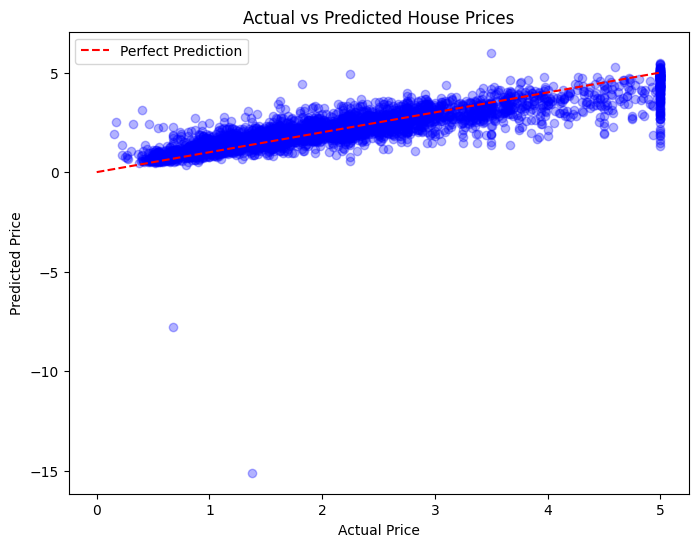

In [20]:
import matplotlib.pyplot as plt

predictions = model.predict(X_test_scaled).flatten()

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.3, color='blue')
plt.plot([0, 5], [0, 5], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.savefig('actual_vs_predicted.png')
plt.show()

Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.2823 - mae: 0.3574 - r2_score: 0.7885 - val_loss: 0.2563 - val_mae: 0.3460 - val_r2_score: 0.8036
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2670 - mae: 0.3547 - r2_score: 0.8000 - val_loss: 0.2606 - val_mae: 0.3429 - val_r2_score: 0.8003
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2736 - mae: 0.3552 - r2_score: 0.7950 - val_loss: 0.2558 - val_mae: 0.3461 - val_r2_score: 0.8039
Epoch 4/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2654 - mae: 0.3521 - r2_score: 0.8011 - val_loss: 0.2575 - val_mae: 0.3446 - val_r2_score: 0.8026
Epoch 5/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2644 - mae: 0.3530 - r2_score: 0.8019 - val_loss: 0.2780 - val_mae: 0.3790 - val_r2_score: 0.7869
Epoch 6/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2604 - mae: 0.3501 - r2_score: 0.8049 - val_loss: 0.2807 - val_mae: 0.3781 - val_r2_score: 0.7848
Epoch 7/20
465/465 ━━━━━━━━━━━━━━━━━━━━

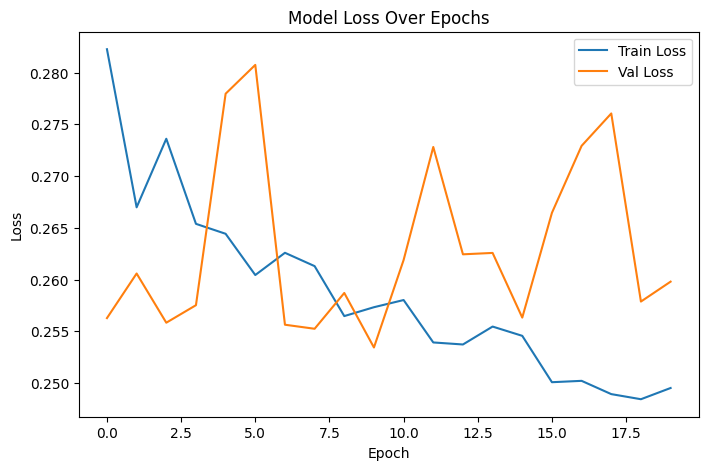

In [21]:
history = model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.1)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_loss.png')
plt.show()

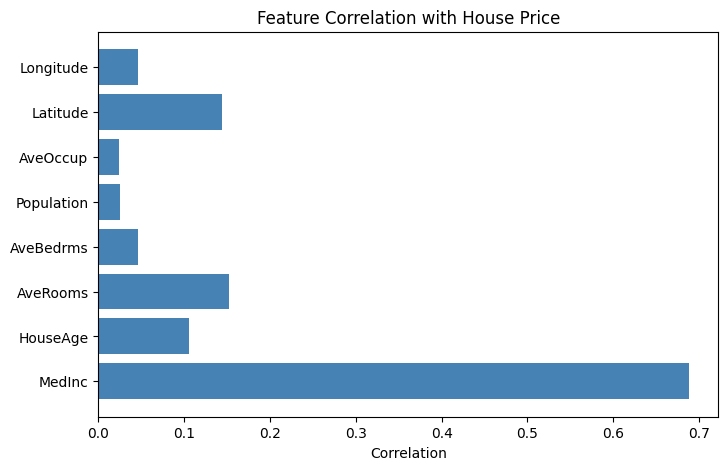

In [22]:
import numpy as np

features = X.columns
correlations = [abs(df[f].corr(df['MedHouseVal'])) for f in features]

plt.figure(figsize=(8,5))
plt.barh(features, correlations, color='steelblue')
plt.title('Feature Correlation with House Price')
plt.xlabel('Correlation')
plt.savefig('feature_importance.png')
plt.show()